# Простые методы предсказания ВР

## Содержание



|раздел | [Nixtla](https://nixtlaverse.nixtla.io/statsforecast/) / [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/)| [FPPPY](https://otexts.com/fpppy/)|
|-------|-----------------------|------|
|QuickStart| [statsforecast](https://nixtlaverse.nixtla.io/statsforecast/docs/getting-started/getting_started_short.html)/[end2end tour](https://nixtlaverse.nixtla.io/statsforecast/docs/getting-started/getting_started_complete.html#train-multiple-models-for-many-series)/ [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/getting-started/getting_Started_short.ipynb) [GitHub2](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/getting-started/getting_Started_complete.ipynb)| [Chp1](https://otexts.com/fpppy/nbs/01-intro.html), [5.1](https://otexts.com/fpppy/nbs/05-toolbox.html)|
|Naive |    [models_intro](https://nixtlaverse.nixtla.io/statsforecast/src/core/models_intro.html)   | [5.2](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-simple-methods)|
|ExpSmooth | [automatic_forecasting](https://nixtlaverse.nixtla.io/statsforecast/docs/how-to-guides/automatic_forecasting.html),/[ETS at scale](https://nixtlaverse.nixtla.io/statsforecast/docs/experiments/ets_ray_m5.html) [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/models/AutoETS.ipynb)| [Chapter 8](https://otexts.com/fpppy/nbs/08-exponential-smoothing.html)|
|STL | [MSTL](https://nixtlaverse.nixtla.io/statsforecast/docs/tutorials/multipleseasonalities.html) [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/tutorials/MultipleSeasonalities.ipynb)  |[3.6](https://otexts.com/fpppy/nbs/03-decomposition.html#sec-stl), [5.7](https://otexts.com/fpppy/nbs/05-toolbox.html#sec-forecasting-decomposition), [12.1](https://otexts.com/fpppy/nbs/12-advanced.html#sec-complexseasonality)|
|Prophet|    [forecast-function-using-prophet](https://nixtlaverse.nixtla.io/statsforecast/docs/experiments/prophet_spark_m5.html#forecast-function-using-prophet) [GitHub](https://github.com/Nixtla/statsforecast/tree/main/nbs/docs/experiments) | [12.2](https://otexts.com/fpppy/nbs/12-advanced.html#sec-prophet) |

* [Effortless Accuracy Unlocking the Power of Baseline Forecasts](https://www.nixtla.io/blog/baseline-forecasts)
* [Out-of-Sample Time Series Forecasting (TSF) via Auto models](https://readmedium.com/out-of-sample-time-series-forecasting-tsf-via-nixtlas-statsforecast-autoarima-autoets-0e163a22d9cb)
* [Automatic Time Series Forecasting](https://nixtlaverse.nixtla.io/statsforecast/docs/how-to-guides/automatic_forecasting.html) / [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/how-to-guides/Automatic_Forecasting.ipynb)
* [Auto models selection statforecast](https://www.nixtla.io/blog/statsforecast-automatic-model-selection)
* [arima_prophet_adapter](https://github.com/Nixtla/statsforecast/blob/main/experiments/arima_prophet_adapter/README.md)
* [StatForecast in AutoGluno using](https://readmedium.com/autogluon-timeseries-every-time-series-forecasting-model-in-one-library-29a3bf6879db)

## Библиотеки экосистемы анализа временных рядов Nixtla 

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [96]:
from statsforecast import StatsForecast
from statsforecast.models import *

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, rmse, smape, mase

In [97]:
from TSC_Nixtla_dump import *
plt_style_GOST()

### Загрузка данных

Загрузим данные

In [98]:
df_ = pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df_.head(1)

,Consumption,Wind,Solar,temperature,radiation_direct_horizontal,hour,month,day_of_week,Consumption_detrended,season,day_of_week_str,daylight_duration,week,is_holiday,Consumption_resid,Wind_resid,Solar_resid,temperature_resid,radiation_direct_horizontal_resid
time,,,,,,,,,,,,,,,,,,,
2015-01-01,41.151,8.852,0.071,-0.981,0.0,0,1,3,-7.29271,Winter,Thu,7.921998,1,True,0.136794,0.610749,0.382488,-4.475639,-7.584582


Выберем ВР для дальнейшего анализа

In [99]:
ts = ['Consumption','Wind',	'Solar']
exog_cols = ['temperature','radiation_direct_horizontal']

Для простоты освоения инструментов возьмам данные только с самым длинным периодом. То есть усредрим все более быстрые колебания. Данные будем рассматривать с шагом в неделю. У нас остается 1 сезонная компонента со значением сезона - 53 недели (1 год)

In [100]:
y = df_.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
})

y = y.iloc[1:-2]

### Приведение данных к long формату

#### Преобразуем временной ряд к стандартному для `Nixtla` виду `panel`. 

Такой формат данных это по сути т.н. long данные - когда все ВР составлены в столбец. И каждый ВР выбирается по уникальному идентификатору.

Для этого создадим соответствующие столбцы:
* `ds` - временные метки.
* `unique_id` - название временного ряда. Это будет полезно при использовании многопеременных или иерархических временных рядов.
* `y` - целевая переменная ВР. В случае ногопеременных или иерархических временных рядов метки будут разделяться по их `unique_id`.

Такой формат [с укажанием id каждой записи](https://nixtlaverse.nixtla.io/neuralforecast/examples/data_format.html) представления временных рядов известен как [<tt>long format</tt>](https://www.theanalysisfactor.com/wide-and-long-data/).

In [101]:
ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

,unique_id,ds,y
728,Solar,2019-01-20,255.614
160,Consumption,2018-02-04,10217.104
512,Wind,2019-11-17,2754.354
1,Consumption,2015-01-18,9689.010
301,Wind,2015-11-01,855.241


#### ВР
Проверим, что у нас действительно все датасеты  

In [102]:
panel_df['unique_id'].unique()

array(['Consumption', 'Wind', 'Solar'], dtype=object)

#### Получим частоту для дальнейшей работы

In [103]:
FREQ = y.index.freq
FREQ

<Week: weekday=6>

#### Проверим значенипе сезонности при помощи утилиты `find_season_length`

In [104]:
from coreforecast.seasonal import find_season_length

In [105]:
SEASON = find_season_length(y['Consumption'].values, max_season_length = 55)
SEASON

52

#### экзогенные переменные

Также попробуем добавить экзогенные переменные. Они будут добавляться как дополнительные столбцы где для будут дублироваться для каждого `'unique_id'` по сопостовлению временных меток `ds`

In [106]:
df_exog = y[exog_cols].reset_index()
df_exog['ds'] = date_index
panel_df = panel_df.merge(df_exog, on='ds', how='left')
panel_df = panel_df[[*base_cols, *exog_cols]]
panel_df = panel_df.rename(columns = {'radiation_direct_horizontal':'radiation'})

panel_df.head(2)

,unique_id,ds,y,temperature,radiation
0,Consumption,2015-01-11,9440.105,2.488536,5.554645
1,Consumption,2015-01-18,9689.010,3.012375,7.504608


### Визуализация Временных рядов

#### plot_series
Для визуализации ВР воспользуемся функцией [`plot_series`](https://nixtlaverse.nixtla.io/utilsforecast/plotting.html#plot-series) из библиотеки [`utilsforecast`](https://nixtlaverse.nixtla.io/utilsforecast). Функция имеет несколько "движков", в зависимости от них настройки будут разными. 

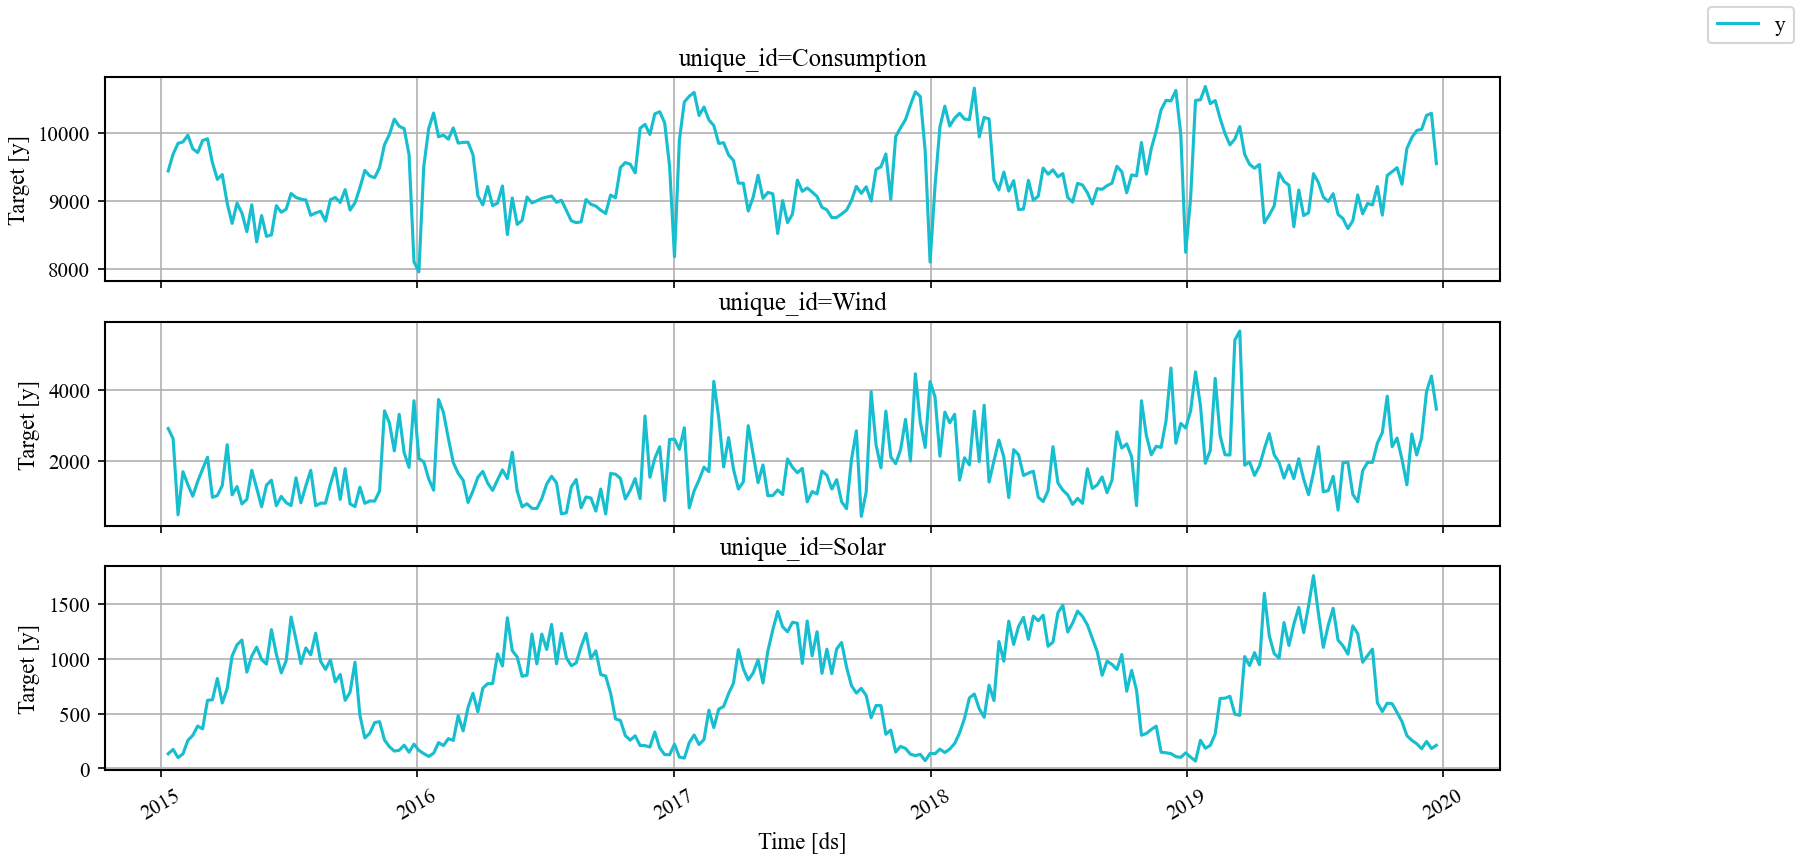

In [107]:
n_rows = len(panel_df['unique_id'].unique())
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2*n_rows), sharex=True)
plot_series(panel_df, ax = ax)

#### Мы будем использовать иногда функцию plot_series_v2

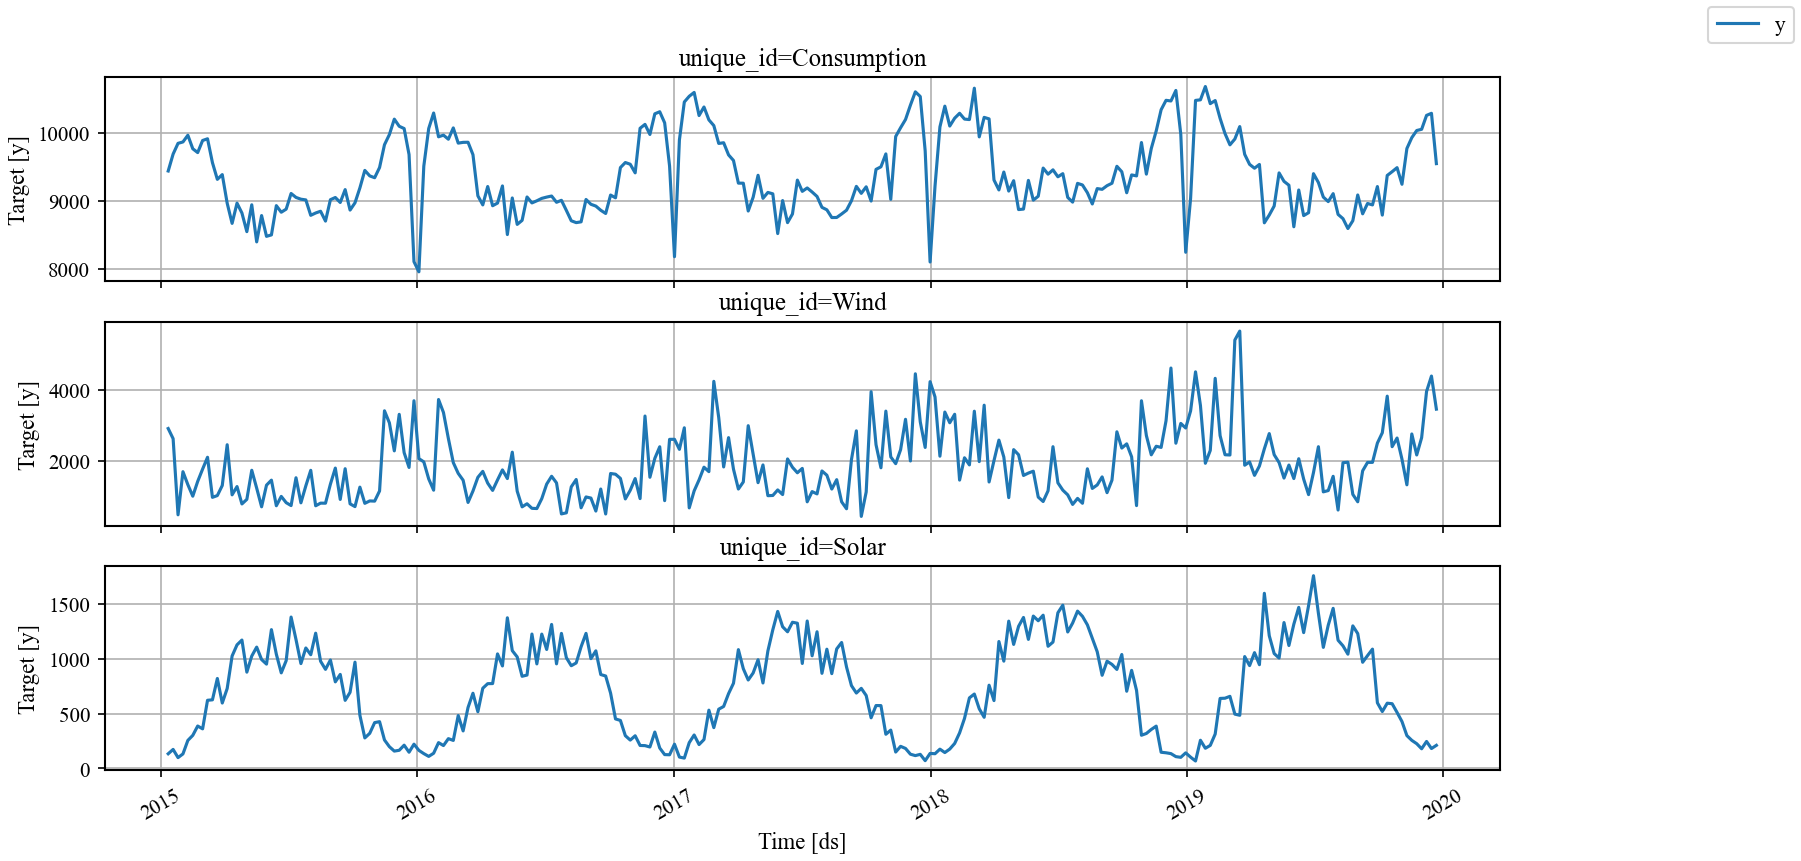

In [108]:
plot_series_v2(panel_df)

### Train Test Split

Разделим ВР на тренировочную и тестовую части. К сожалению на сегодня это возможно только в ручном режиме

In [109]:
FH = int(0.42 * y.shape[0])

In [110]:
df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

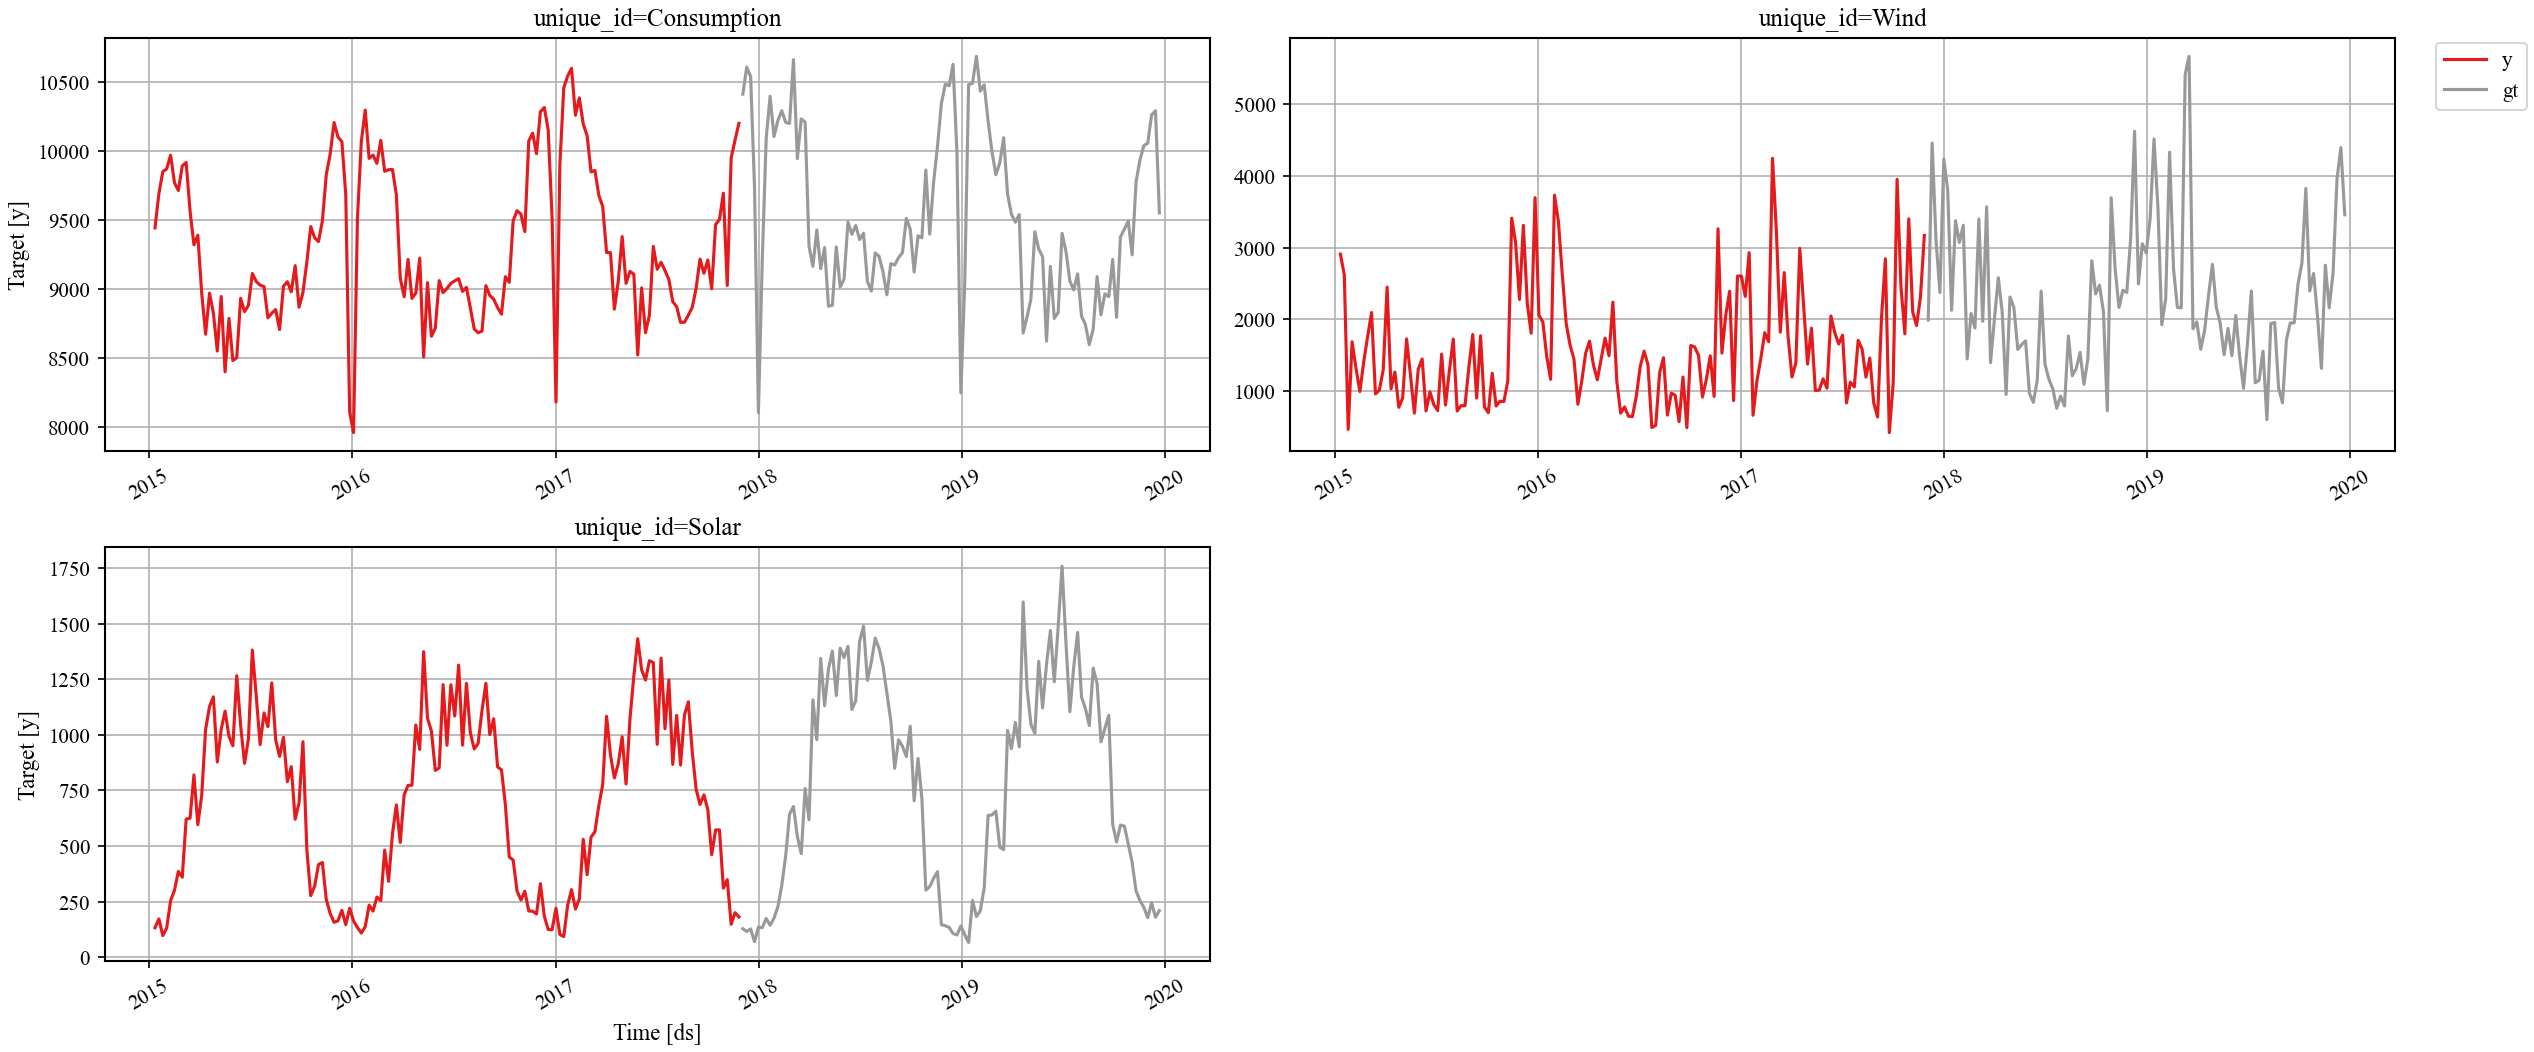

In [111]:
plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

## Дополнительно

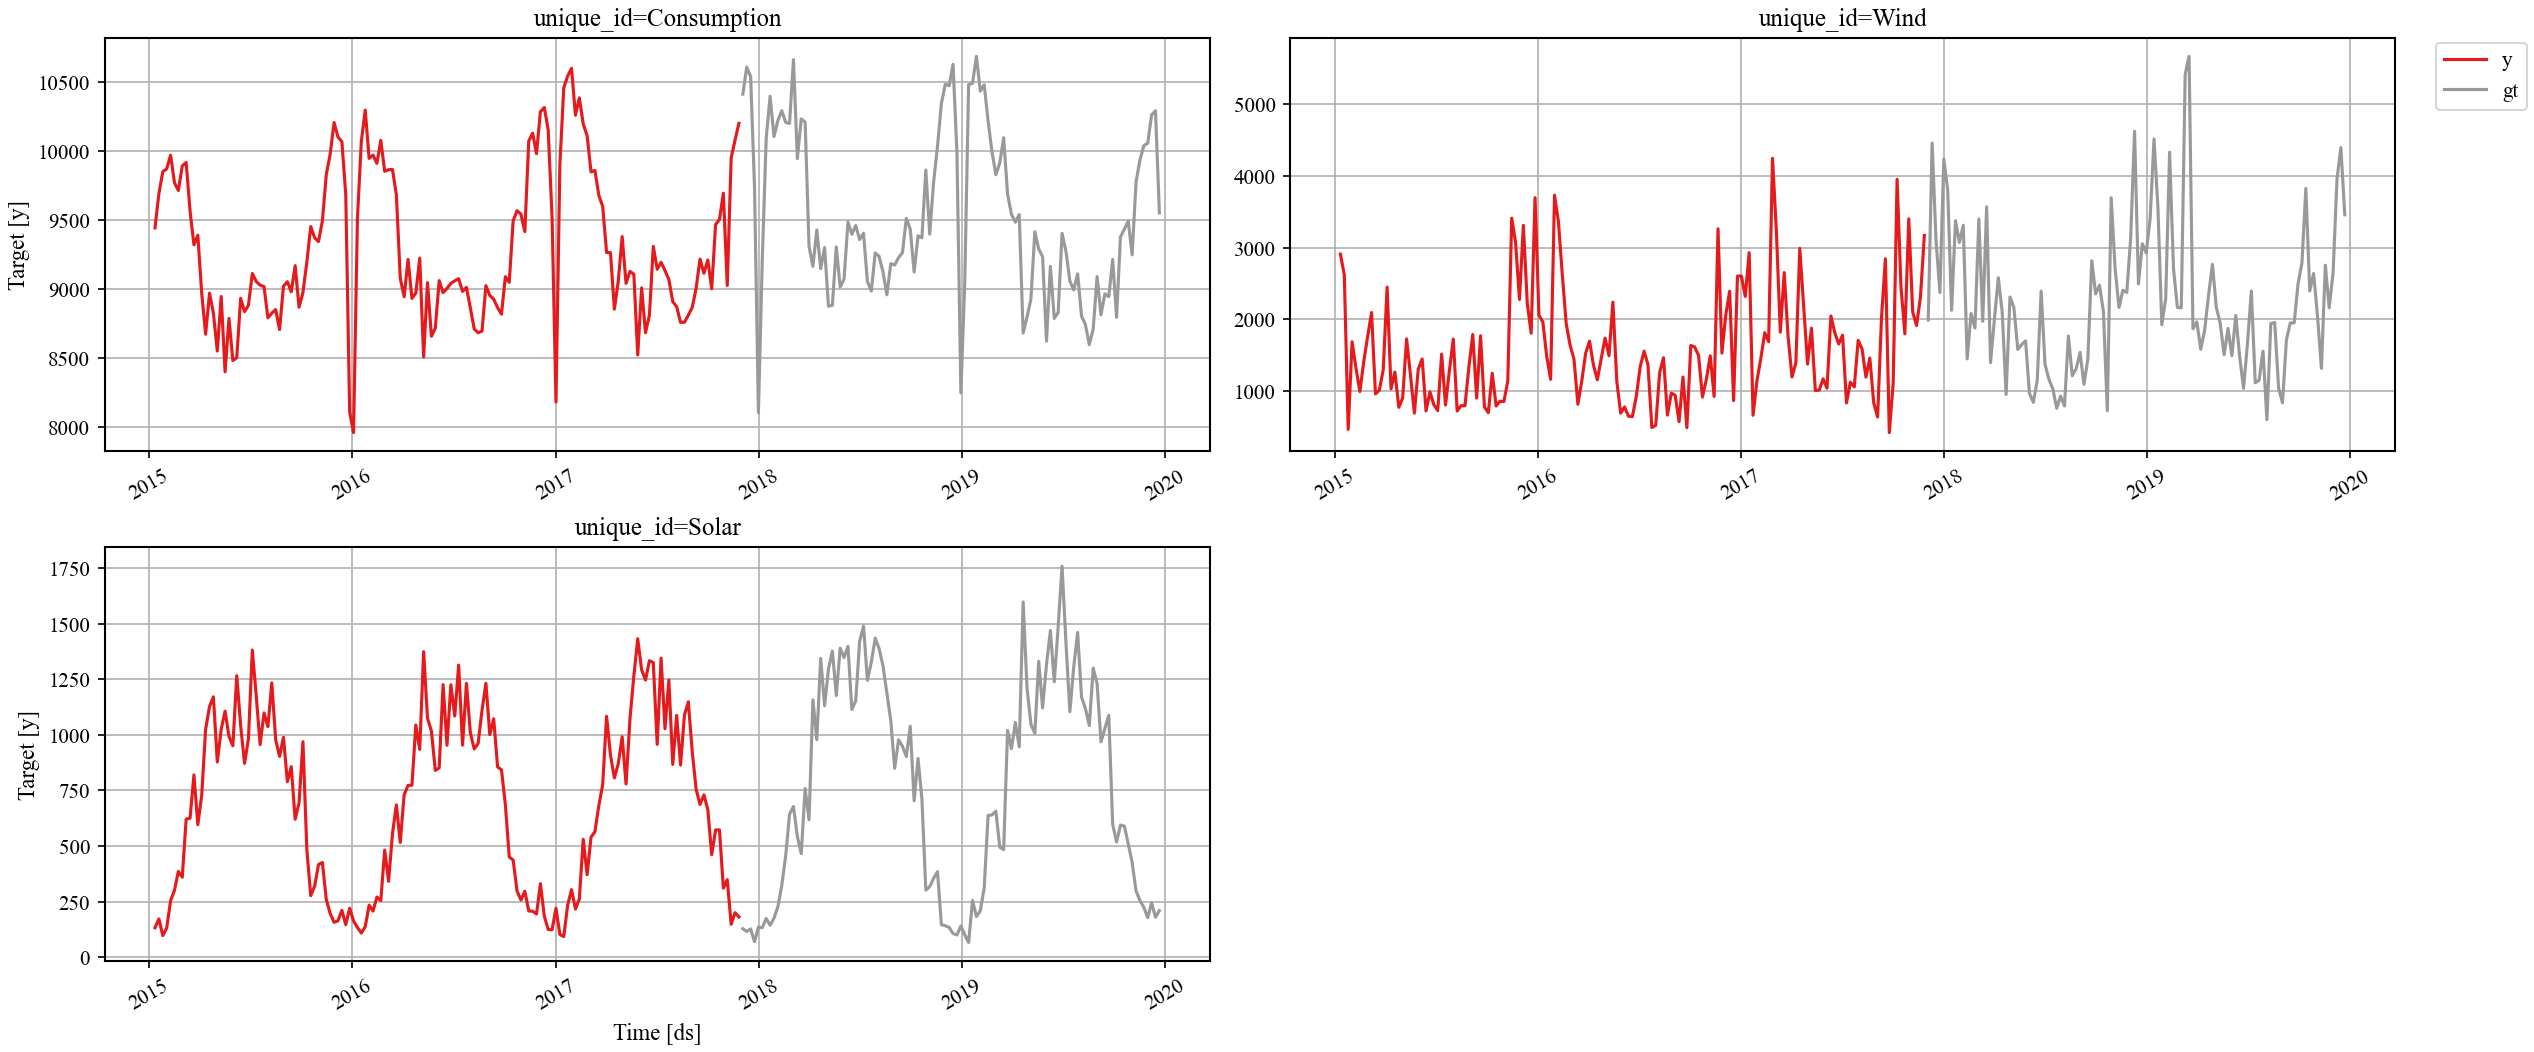

In [112]:
df= pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)

df.head(1)
ts = ['Consumption','Wind',	'Solar']

exog_cols = ['temperature','radiation_direct_horizontal']

y = df.resample('W').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]

ts = ['Consumption', 'Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']

date_index = y.index
panel_list = [pd.DataFrame({'ds':date_index , 'y': y[t].values, 'unique_id': t}) for t in ts]
panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols] #порядок колонок
panel_df.sample(5)

FREQ = y.index.freq

SEASON = 52

FH = int(0.42 * y.shape[0])

df_test  = panel_df[base_cols].groupby("unique_id").tail(FH)
df_train = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)

plot_series(df_train, df_test.rename(columns={"y": "gt"}),  palette='Set1')

In [113]:
# from prophet_adapter import AutoARIMAProphet
from statsforecast.models import AutoARIMA

In [196]:
import numpy as np
import pandas as pd
from typing import Optional, List
from statsforecast.models import _TS
from prophet import Prophet as FBProphet  # оригинальный prophet (fbprophet)

class TSProphet_(_TS):
    """
    Prophet wrapper для StatForecast.
    ВАЖНО: В statsforecast уже есть встроенная модель Prophet — эта обёртка нужна ТОЛЬКО для кастомизации.
    """
    _tags = {
        "python_dependencies": ["prophet"],
        "capability:pred_int": True,  # поддержка prediction intervals
    }

    def __init__(
        self,
        freq: str = 'H',
        growth: str = 'linear',
        yearly_seasonality: bool = True,
        weekly_seasonality: bool = True,
        daily_seasonality: bool = True,
        seasonality_mode: str = 'additive',
        seasonality_prior_scale: float = 10.0,
        holidays: Optional[str] = None,
        country_holidays: Optional[str] = None,
        interval_width: float = 0.8,  # Добавлено
        level: Optional[List[int]] = None,
        **kwargs
    ):
        self.freq = freq
        self.growth = growth
        self.yearly_seasonality = yearly_seasonality
        self.weekly_seasonality = weekly_seasonality
        self.daily_seasonality = daily_seasonality
        self.seasonality_mode = seasonality_mode
        self.seasonality_prior_scale = seasonality_prior_scale
        self.holidays = holidays
        self.country_holidays = country_holidays
        self.interval_width = interval_width  # Добавлено
        self.kwargs = kwargs
        self.level = level
        if self.level:
            self.interval_width = self.level[0] / 100.0 if self.level else interval_width
        
        super().__init__()
        
        self.alias = "Prophet"

    def _create_model(self):
        """Создание модели Prophet с текущими параметрами."""
        model = FBProphet(
            growth=self.growth,
            yearly_seasonality=self.yearly_seasonality,
            weekly_seasonality=self.weekly_seasonality,
            daily_seasonality=self.daily_seasonality,
            seasonality_mode=self.seasonality_mode,
            seasonality_prior_scale=self.seasonality_prior_scale,
            interval_width=self.interval_width,  # Добавлено
            **self.kwargs
        )
        
        if self.country_holidays:
            model.add_country_holidays(country_name=self.country_holidays)
        
        return model
    
    def fit(
        self,
        y: np.ndarray,
        X: Optional[np.ndarray] = None,
    ):
        """
        Обучение на одном временном ряду.
        """
        # Получаем даты из внутреннего контекста StatForecast
        if hasattr(self, '_dates') and self._dates is not None:
            ds = self._dates
        else:
            # Если даты недоступны, используем произвольные даты
            ds = pd.date_range(start='1970-01-01', periods=len(y), freq=self.freq)
        
        # Создаём DataFrame для Prophet
        df = pd.DataFrame({'ds': ds, 'y': y})
        
        # Обучаем модель
        self.model_ = self._create_model()
        self.model_.fit(df)
        
        return self
    
    def predict(
        self,
        h: int,
        X: Optional[np.ndarray] = None,
        level: Optional[List[int]] = None,
    ) -> dict:
        """
        Прогнозирование на горизонт h.
        """
        if not hasattr(self, 'model_'):
            raise RuntimeError("Модель не обучена. Вызовите .fit() перед .predict()")
        
        # Генерация будущих дат
        future = self.model_.make_future_dataframe(periods=h, freq=self.freq, include_history=False)
        
        # Прогноз
        fcst = self.model_.predict(future)
        
        # Формирование результата
        if level is not None:
            res = {
                'mean': fcst['yhat'].values,
                f'lo-{level[0]}': fcst['yhat_lower'].values,
                f'hi-{level[0]}': fcst['yhat_upper'].values
            }
        else:
            # Если level не задан, возвращаем только mean
            res = {'mean': fcst['yhat'].values}
        
        return res

    def predict_in_sample(
        self,
        level: Optional[List[int]] = None,
    ) -> dict:
        """
        In-sample прогнозы (на обучающих данных).
        """
        if not hasattr(self, 'model_'):
            raise RuntimeError("Модель не обучена")
        
        # Получаем прогноз на обучающий период
        history = self.model_.history
        fcst = self.model_.predict(history)
        
        # Всегда возвращаем одинаковое количество колонок для совместимости
        if self.level:
            primary_level = self.level[0]
            res = {
                'fitted': fcst['yhat'].values,
                f'lo-{primary_level}': fcst['yhat_lower'].values,
                f'hi-{primary_level}': fcst['yhat_upper'].values
            }
        else:
            # Возвращаем только fitted, но в формате с 3 колонками для совместимости
            res = {
                'fitted': fcst['yhat'].values,
                'lo-80': fcst['yhat_lower'].values,
                'hi-80': fcst['yhat_upper'].values
            }
        
        return res

    def forecast(
        self,
        y: np.ndarray,
        h: int,
        X: Optional[np.ndarray] = None,
        X_future: Optional[np.ndarray] = None,
        level: Optional[List[int]] = None,
        fitted: bool = False,
    ):
        """
        Обучение и прогнозирование.
        """
        self.fit(y, X)
        pred = self.predict(h=h, X=X_future, level=level)
        if fitted:
            pred['fitted'] = self.predict_in_sample(level=level)['fitted']
        return pred
    
    def forward(
        self,
        y: np.ndarray,
        h: int,
        X: Optional[np.ndarray] = None,
        X_future: Optional[np.ndarray] = None,
        level: Optional[List[int]] = None,
        fitted: bool = False,
    ):
        """
        Прогнозирование на новых данных без повторного обучения.
        """
        pred = self.predict(h=h, X=X_future, level=level)
        if fitted:
            pred['fitted'] = self.predict_in_sample(level=level)['fitted']
        return pred

In [198]:
from statsforecast import StatsForecast
LEVELS = None

models = [TSProphet_(freq=FREQ, yearly_seasonality=True, level = LEVELS, )]

sf = StatsForecast(models=models, freq=FREQ, n_jobs=1)

fcst_sf = sf.forecast(df=df_train, h=FH, level = LEVELS, fitted=True)

in_sample = sf.forecast_fitted_values()

eval_sf = df_test.merge(fcst_sf, on=['unique_id', 'ds'])

18:54:31 - cmdstanpy - INFO - Chain [1] start processing
18:54:31 - cmdstanpy - INFO - Chain [1] done processing
18:54:31 - cmdstanpy - INFO - Chain [1] start processing
18:54:31 - cmdstanpy - INFO - Chain [1] done processing
18:54:31 - cmdstanpy - INFO - Chain [1] start processing
18:54:31 - cmdstanpy - INFO - Chain [1] done processing


In [199]:
in_sample

,unique_id,ds,y,Prophet
0,Consumption,2015-01-11,9440.105,9249.608170
1,Consumption,2015-01-18,9689.010,9888.017552
2,Consumption,2015-01-25,9847.035,10180.996227
3,Consumption,2015-02-01,9867.317,10083.323112
4,Consumption,2015-02-08,9966.415,9854.988173
...,...,...,...,...
448,Wind,2017-10-29,3400.181,1622.722594
449,Wind,2017-11-05,2105.870,1742.504163
450,Wind,2017-11-12,1914.513,2248.422191
451,Wind,2017-11-19,2309.436,2797.618053


In [200]:
fcst_sf

,unique_id,ds,Prophet
0,Consumption,2017-12-03,10494.164951
1,Consumption,2017-12-10,10295.148846
2,Consumption,2017-12-17,9681.978700
3,Consumption,2017-12-24,9027.668251
4,Consumption,2017-12-31,8800.376089
...,...,...,...
319,Wind,2019-11-24,3382.193123
320,Wind,2019-12-01,3255.747531
321,Wind,2019-12-08,2900.686068
322,Wind,2019-12-15,2748.486104


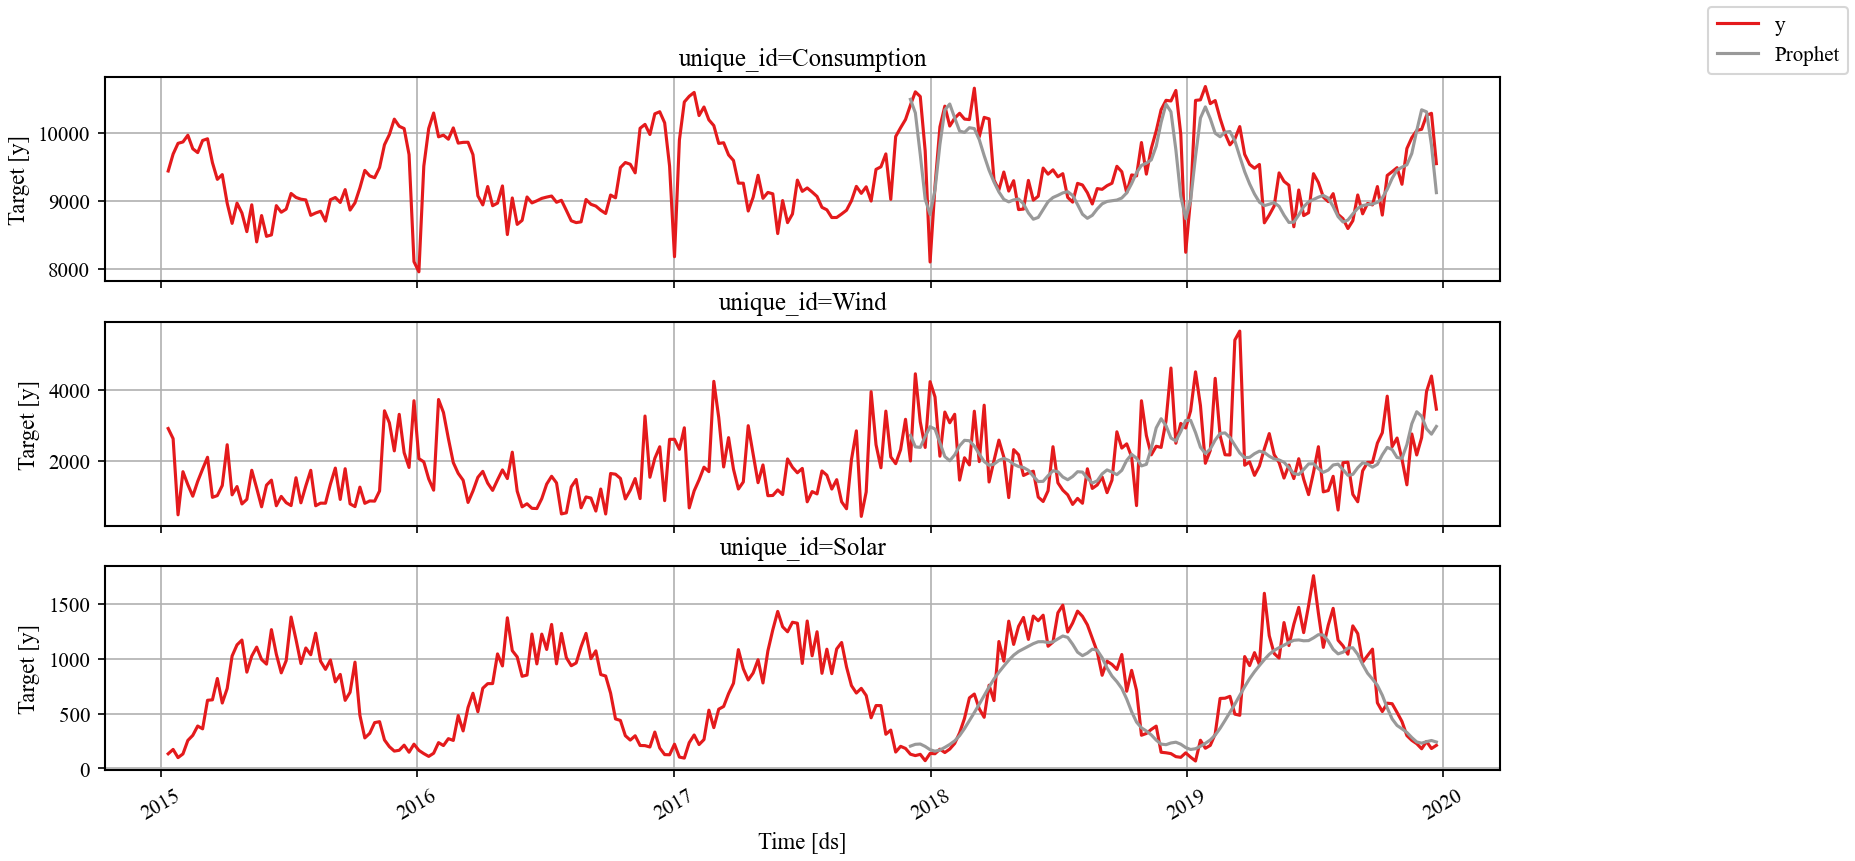

In [201]:

evaluate_and_plot(df_train, df_test, eval_sf, metrics = [mae, rmse, ], levels=LEVELS)